# 3 - Dissonance + Chromaticism

## Imports

In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [7]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

In [9]:
metadata = g.load_metadata()
subset = metadata[metadata['fnames'] == "Autumn Leaves - Chet Bake_Desmond (Concert Key)"]
subset

,rel_paths,fnames,last_mc,last_mn,KeySig,TimeSig,label_count,annotated_key,composer,workTitle,...,staff_7_ambitus,staff_7_instrument,staff_8_ambitus,staff_8_instrument,staff_9_ambitus,staff_9_instrument,transcribed_instruments,transcribed_sections,transposition,year_certain
13,by_Carles_Margarit,Autumn Leaves - Chet Bake_Desmond (Concert Key),191,190,1: -2,1: 4/4,245,NaN,"Joseph Kosma, Johnny Mercer, Jacques Pr�vert",Autumn Leaves,...,NaN,NaN,NaN,NaN,NaN,NaN,"tp, as",solo,Concert Key,1


## Dissonance

In [61]:
ILC = g.load_labels(metadata)
ILC['dissonance'] = ILC['label'].apply(ia.label_to_dissonance)

ILC['dissonance'] = ILC['dissonance'] * ILC['duration_qb']

identifier = ['artist', 'workTitle', 'recording_year']
ILC = ILC.groupby(by=identifier, as_index=False)['dissonance', 'duration_qb'].sum()
ILC['dissonance'] = ILC['dissonance'] / ILC['duration_qb']
ILC

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_8365/22687912.py:7: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  ILC = ILC.groupby(by=identifier, as_index=False)['dissonance', 'duration_qb'].sum()


,artist,workTitle,recording_year,dissonance,duration_qb
0,Arturo Sandoval,There Will Never Be Another You,2012,0.554500,400.0
1,Baptiste Trotignon,Que Reste-t-il De Nos Amours,2017,0.550391,256.0
2,Ben Sluijs,Flying Circles,2002,0.622780,244.0
3,Bert Joris,Happy Tears,2005,0.386458,192.0
4,Bob Mintzer,12 Keys Blues,2010,0.628296,622.0
...,...,...,...,...,...
146,Wayne Shorter,Stella By Starlight,1990,0.722435,1080.0
147,Wayne Shorter,Yes Or No,1964,0.381187,943.0
148,Woody Shaw,There Will Never Be Another You,1986,0.534000,400.0
149,"Woody Shaw, Kenny Garrett",There Will Never Be Another You,1986,0.533727,656.0


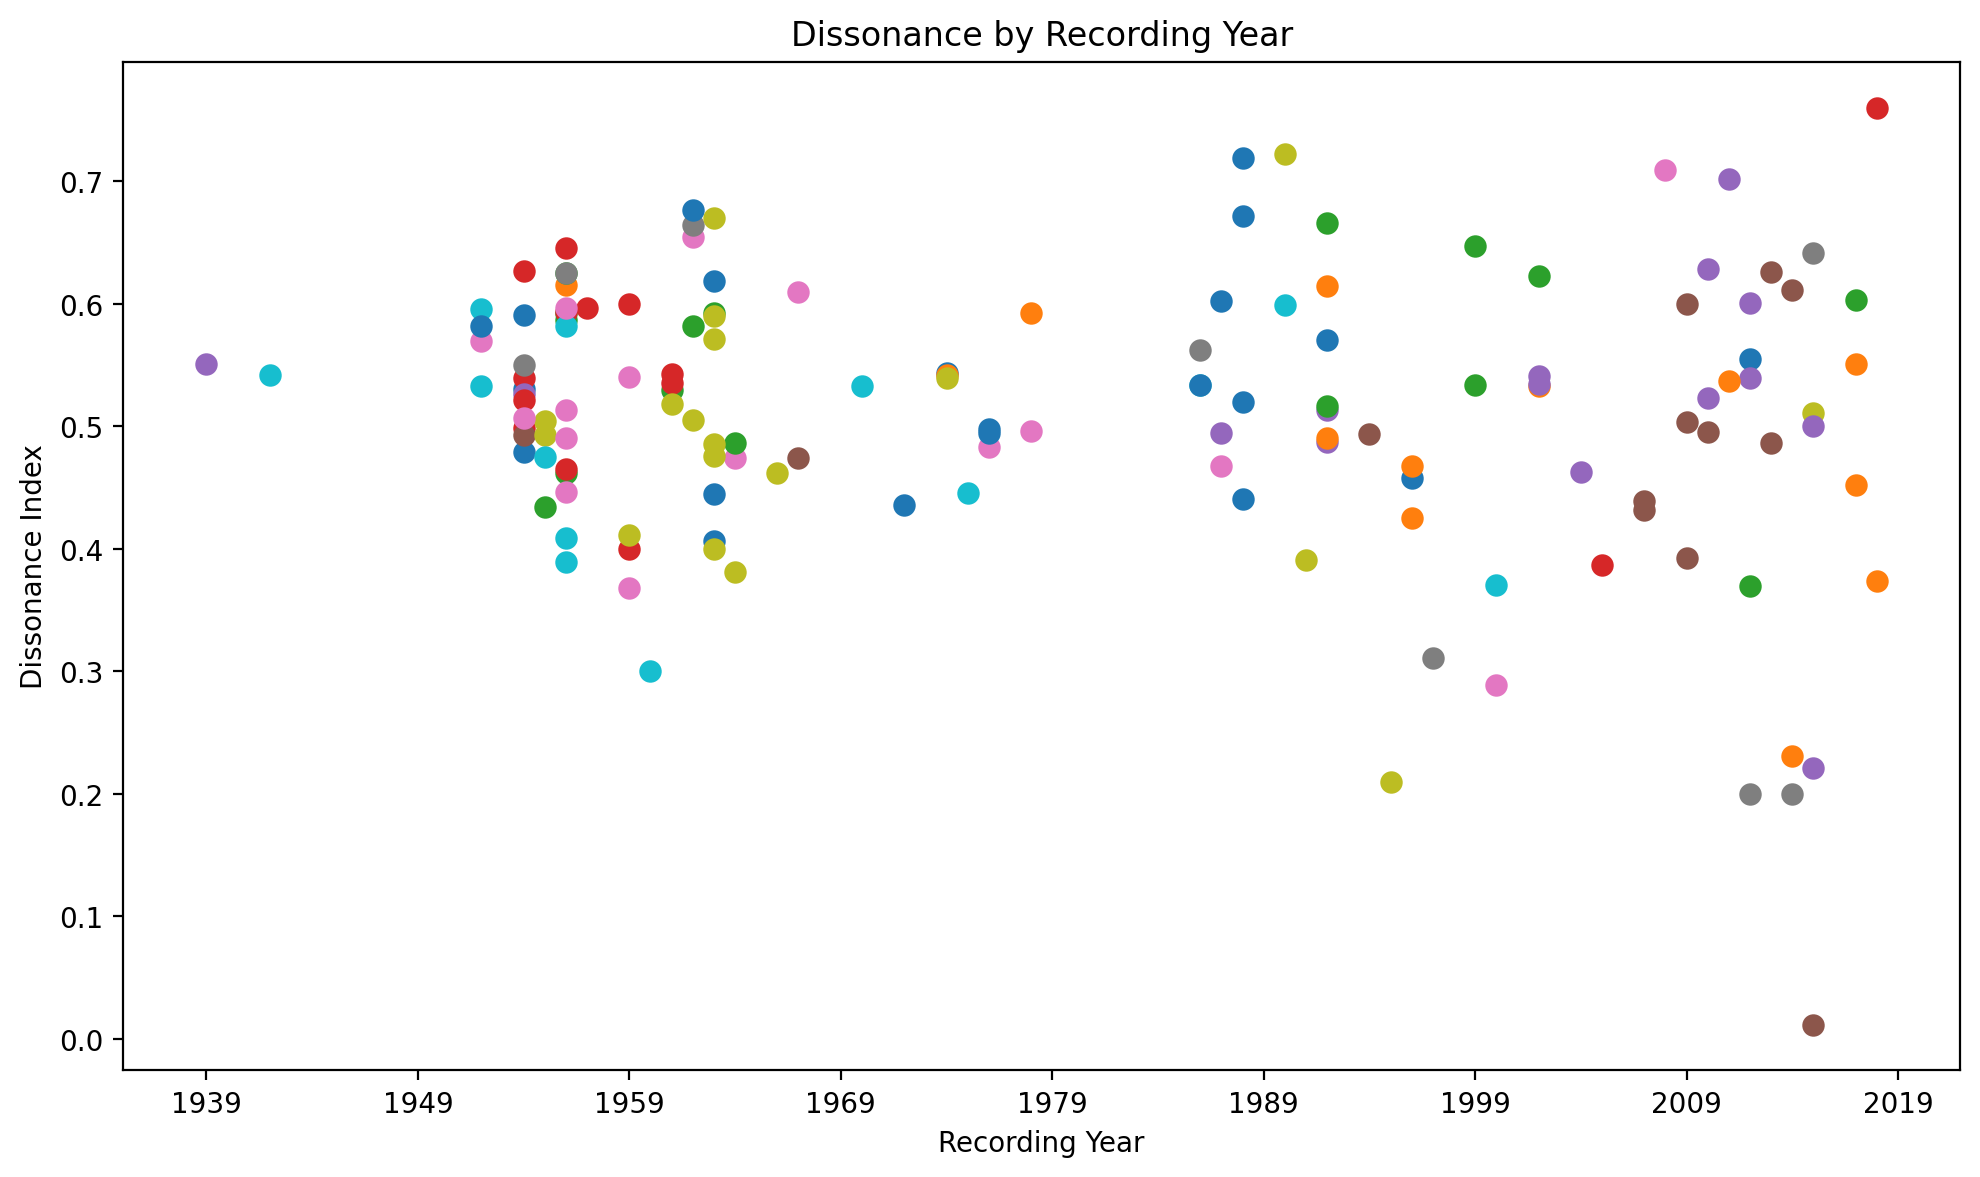

In [65]:
plt.figure(figsize=(10, 6))


ILC['recording_year'] = pd.to_numeric(ILC['recording_year'], errors='coerce')
min_year = ILC['recording_year'].min()
max_year = ILC['recording_year'].max()

# Set tick locations — every 10 years
ticks = np.arange(min_year, max_year+10, 10)

# Unique artists
artists = ILC['artist'].unique()

# Colormap
colors = plt.cm.tab10.colors  # or any colormap you like

# Plot each artist separately
for i, artist in enumerate(artists):
    subset = ILC[ILC['artist'] == artist]
    plt.scatter(subset['recording_year'], subset['dissonance'],
                label=artist, color=colors[i % len(colors)], s=50)

plt.xticks(ticks)

# Labels and title
plt.title('Dissonance by Recording Year')
plt.xlabel('Recording Year')
plt.ylabel('Dissonance Index')
#plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

## Chromaticism

In [71]:
notes = g.load_notes(subset) 
notes 

,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,gracenote,nominal_duration,...,pc,note,time,artist,workTitle,fnames,rel_paths,recording_year,label,ILS
0,1,0,0.125,3/8,4/4,1,1,0.125,NaN,1/8,...,7,G,1.125,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,NaN,NaN
1,1,0,0.250,1/2,4/4,1,1,0.125,NaN,1/8,...,9,A,1.250,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,NaN,NaN
2,1,0,0.375,5/8,4/4,1,1,0.250,NaN,1/4,...,10,Bb,1.375,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,NaN,NaN
3,1,0,0.625,7/8,4/4,1,1,0.125,NaN,1/8,...,3,Eb,1.625,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,NaN,NaN
4,2,1,0.000,0,4/4,1,1,1.000,NaN,1,...,3,Eb,2.000,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Cmin7,"[C, E-, G, B-]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,189,188,0.625,5/8,4/4,1,1,0.125,NaN,1/8,...,0,C,189.625,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Gmin7,"[G, B-, D, F]"
807,189,188,0.750,3/4,4/4,1,1,0.125,NaN,1/8,...,9,A,189.750,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Gmin7,"[G, B-, D, F]"
808,189,188,0.875,7/8,4/4,1,1,0.125,NaN,1/8,...,10,Bb,189.875,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Gmin7,"[G, B-, D, F]"
809,190,189,0.000,0,4/4,1,1,1.000,NaN,1,...,9,A,190.000,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Gmin7,"[G, B-, D, F]"


In [85]:
import math
def in_ILS(note_name, ils_list):
    if isinstance(ils_list, float) and math.isnan(ils_list):
        return np.nan

    n = m21.note.Note(note_name)

    if n.name in ils_list:
        return True
    else:
        return False

notes['in_ILS?'] = notes.apply(lambda row: in_ILS(row['note'], row['ILS']), axis=1)
notes

,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,gracenote,nominal_duration,...,note,time,artist,workTitle,fnames,rel_paths,recording_year,label,ILS,in_ILS?
0,1,0,0.125,3/8,4/4,1,1,0.125,NaN,1/8,...,G,1.125,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,NaN,NaN,NaN
1,1,0,0.250,1/2,4/4,1,1,0.125,NaN,1/8,...,A,1.250,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,NaN,NaN,NaN
2,1,0,0.375,5/8,4/4,1,1,0.250,NaN,1/4,...,Bb,1.375,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,NaN,NaN,NaN
3,1,0,0.625,7/8,4/4,1,1,0.125,NaN,1/8,...,Eb,1.625,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,NaN,NaN,NaN
4,2,1,0.000,0,4/4,1,1,1.000,NaN,1,...,Eb,2.000,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Cmin7,"[C, E-, G, B-]",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,189,188,0.625,5/8,4/4,1,1,0.125,NaN,1/8,...,C,189.625,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Gmin7,"[G, B-, D, F]",False
807,189,188,0.750,3/4,4/4,1,1,0.125,NaN,1/8,...,A,189.750,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Gmin7,"[G, B-, D, F]",False
808,189,188,0.875,7/8,4/4,1,1,0.125,NaN,1/8,...,Bb,189.875,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Gmin7,"[G, B-, D, F]",True
809,190,189,0.000,0,4/4,1,1,1.000,NaN,1,...,A,190.000,"Chet Baker, Paul Desmond",Autumn Leaves,Autumn Leaves - Chet Bake_Desmond (Concert Key),by_Carles_Margarit,1974,Gmin7,"[G, B-, D, F]",False
